In [3]:
#importing the required libraries
import pandas as pd

In [4]:
#loading the dataset
df = pd.read_csv('telecom_fraud_detection_dataset.csv')

print(df.head())

       call_id  caller_age_days  calls_per_day  call_duration_sec  \
0  CALL0000001              735              7                449   
1  CALL0000002               63              4                 29   
2  CALL0000003              473             24                 61   
3  CALL0000004               91           1270                 27   
4  CALL0000005               14           1344                 69   

   avg_call_duration_sec  unique_receivers_24h  receiver_block_rate  \
0                  372.5                     9                12.60   
1                   26.3                     8                52.01   
2                   72.8                     6                 5.24   
3                   37.1                   156                36.88   
4                   64.8                   135                72.19   

   spam_reports_count  country_code_risk_score  night_call_ratio  \
0                   4                    26.08             15.18   
1                   2 

In [5]:
#shape of the dataset
print(df.shape)

(10000, 15)


In [6]:
#checking the columns of the dataset
print(df.columns)

Index(['call_id', 'caller_age_days', 'calls_per_day', 'call_duration_sec',
       'avg_call_duration_sec', 'unique_receivers_24h', 'receiver_block_rate',
       'spam_reports_count', 'country_code_risk_score', 'night_call_ratio',
       'sequential_dialing_score', 'graph_degree',
       'previous_fraud_associations', 'reputation_score', 'fraud_label'],
      dtype='object')


In [7]:
#checking the data types
print(df.dtypes)

call_id                         object
caller_age_days                  int64
calls_per_day                    int64
call_duration_sec                int64
avg_call_duration_sec          float64
unique_receivers_24h             int64
receiver_block_rate            float64
spam_reports_count               int64
country_code_risk_score        float64
night_call_ratio               float64
sequential_dialing_score       float64
graph_degree                     int64
previous_fraud_associations      int64
reputation_score               float64
fraud_label                      int64
dtype: object


In [8]:
#statistical summary of the dataset
df.describe()

,caller_age_days,calls_per_day,call_duration_sec,avg_call_duration_sec,unique_receivers_24h,receiver_block_rate,spam_reports_count,country_code_risk_score,night_call_ratio,sequential_dialing_score,graph_degree,previous_fraud_associations,reputation_score,fraud_label
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,773.626600,237.47800,213.367100,210.615840,50.356400,25.088838,18.030500,38.600140,31.241817,33.093151,163.497400,5.043000,63.496163,0.30000
std,728.549185,406.43526,163.899768,177.032595,77.776385,26.525415,32.166751,22.141158,22.258562,27.996123,149.269361,9.117415,26.654174,0.45828
min,0.000000,1.00000,1.000000,1.000000,0.000000,0.090000,0.000000,0.400000,0.180000,0.180000,1.000000,0.000000,0.360000,0.00000
25%,244.000000,6.00000,62.000000,55.800000,7.000000,5.960000,1.000000,20.590000,13.620000,11.310000,61.000000,0.000000,43.080000,0.00000
50%,618.000000,13.00000,198.000000,182.100000,9.000000,11.460000,2.000000,35.620000,24.810000,21.110000,108.000000,0.000000,72.730000,0.00000
75%,1088.000000,317.25000,314.000000,311.125000,73.000000,46.117500,4.000000,54.740000,45.662500,56.102500,220.000000,2.000000,84.882500,1.00000
max,3650.000000,1500.00000,1170.000000,1404.900000,524.000000,98.340000,111.000000,99.220000,98.220000,99.660000,1000.000000,41.000000,99.770000,1.00000


In [9]:
#comparing fraud vs normal calls
df.groupby('fraud_label').mean(numeric_only=True)

,caller_age_days,calls_per_day,call_duration_sec,avg_call_duration_sec,unique_receivers_24h,receiver_block_rate,spam_reports_count,country_code_risk_score,night_call_ratio,sequential_dialing_score,graph_degree,previous_fraud_associations,reputation_score
fraud_label,,,,,,,,,,,,,
0,994.636571,37.447714,280.005143,278.7198,11.734143,9.069129,1.480143,28.42768,19.878446,16.595264,99.416143,0.399571,78.519430
1,257.936667,704.215333,57.878333,51.7066,140.475000,62.468160,56.648000,62.33588,57.756350,71.588220,313.020333,15.877667,28.441873


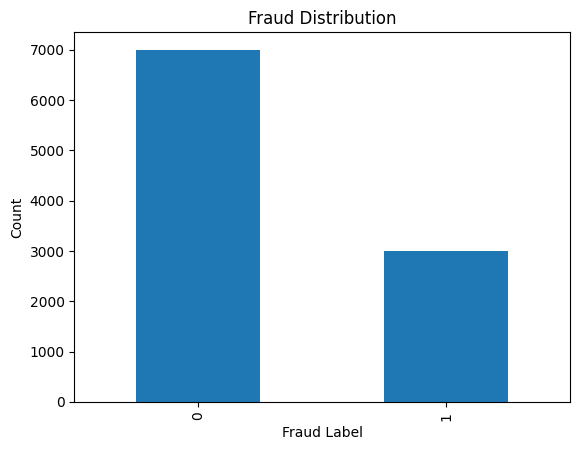

In [16]:
#Visual Analysis
import matplotlib.pyplot as plt

df['fraud_label'].value_counts().plot(kind='bar')

plt.title("Fraud Distribution")
plt.xlabel("Fraud Label")
plt.ylabel("Count")
plt.show()

<Figure size 800x500 with 0 Axes>

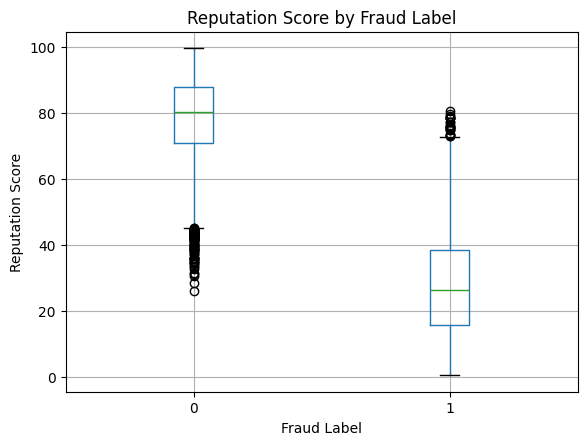

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.boxplot(column='reputation_score', by='fraud_label')

plt.title("Reputation Score by Fraud Label")
plt.suptitle("")  # Removes the automatic subtitle
plt.xlabel("Fraud Label")
plt.ylabel("Reputation Score")

plt.show()

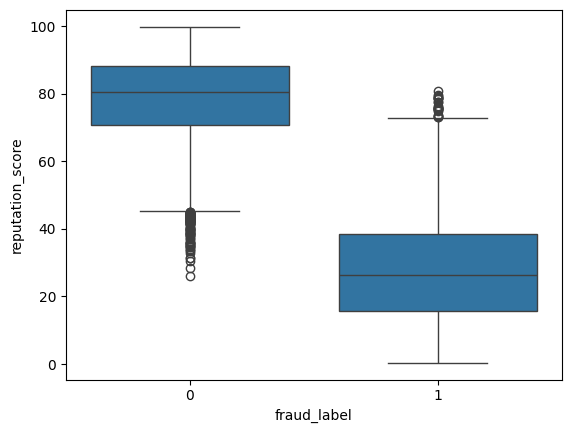

In [11]:
#Repuation Score

import seaborn as sns

sns.boxplot(
    x='fraud_label',
    y='reputation_score',
    data=df
)

plt.show()

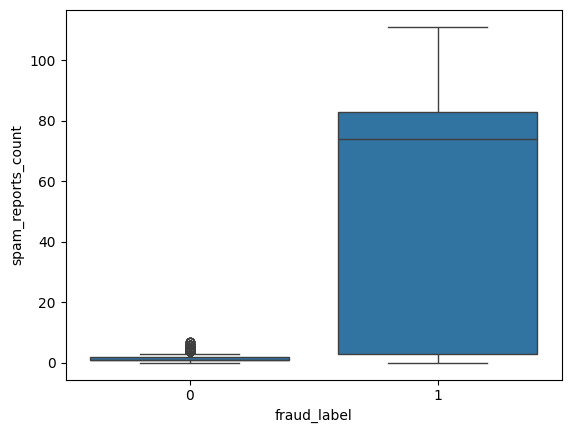

In [12]:
#Spam Report

sns.boxplot(
    x='fraud_label',
    y='spam_reports_count',
    data=df
)

plt.show()

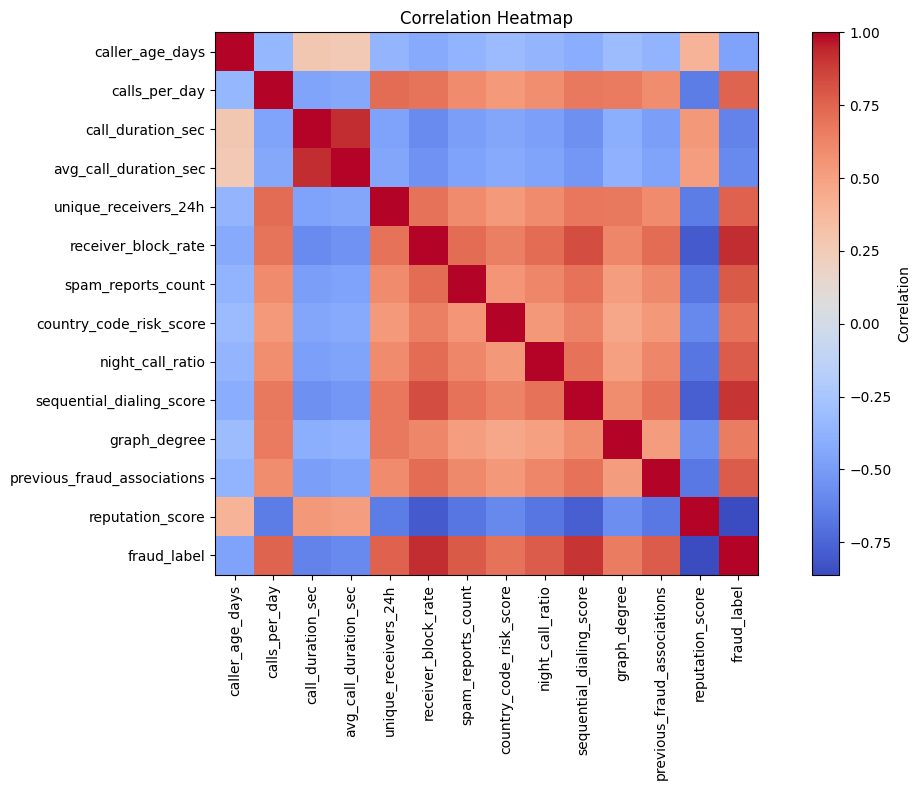

In [18]:
#Correlation Analysis

import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df.drop(columns=['call_id']).corr(numeric_only=True)

# Create a larger figure
plt.figure(figsize=(12, 8))

# Display the heatmap
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')

# Add labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [19]:
corr['fraud_label'].sort_values(ascending=False)

fraud_label                    1.000000
receiver_block_rate            0.922577
sequential_dialing_score       0.900203
spam_reports_count             0.785978
night_call_ratio               0.779866
previous_fraud_associations    0.777996
unique_receivers_24h           0.758578
calls_per_day                  0.751821
country_code_risk_score        0.701836
graph_degree                   0.655799
caller_age_days               -0.463408
avg_call_duration_sec         -0.587664
call_duration_sec             -0.621089
reputation_score              -0.861012
Name: fraud_label, dtype: float64

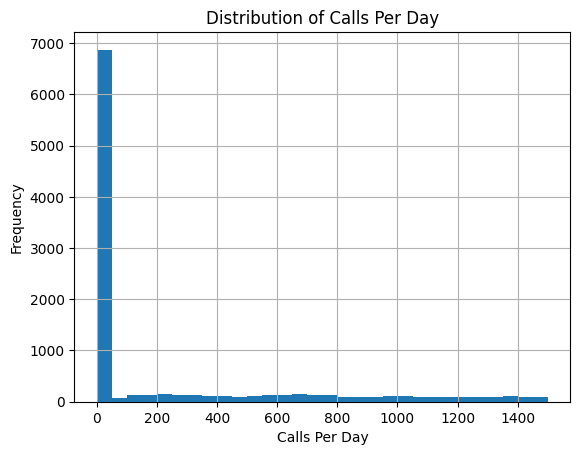

In [21]:
import matplotlib.pyplot as plt

df['calls_per_day'].hist(bins=30)

plt.title("Distribution of Calls Per Day")
plt.xlabel("Calls Per Day")
plt.ylabel("Frequency")

plt.show()